In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout

In [ ]:
# Load Dataset

vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

In [ ]:
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


In [ ]:
#Build Model Function

def create_model(model_type):
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Train Models

model_names = ["RNN", "LSTM", "GRU"]
histories = {}
results = {}

for name in model_names:
    print("\n==============================")
    print("Training:", name)
    print("==============================")

    model = create_model(name)

    start_time = time.time()

    history = model.fit(
        x_train,
        y_train,
        epochs=4,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    end_time = time.time()

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    histories[name] = history
    results[name] = {
        "model": model,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "training_time": end_time - start_time
    }


Training: RNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6658 - loss: 0.5939 - val_accuracy: 0.7210 - val_loss: 0.5525
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8407 - loss: 0.3799 - val_accuracy: 0.7954 - val_loss: 0.4601
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8985 - loss: 0.2575 - val_accuracy: 0.7956 - val_loss: 0.4821
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9663 - loss: 0.1047 - val_accuracy: 0.7784 - val_loss: 0.6055

Training: LSTM
Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7605 - loss: 0.4747 - val_accuracy: 0.8630 - val_loss: 0.3494
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9011 - loss: 0.2607 - val_accuracy: 0.8754 - val_loss: 0.3132
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9245 - loss: 0.2044 - val_accuracy: 0.8712 - val_loss: 0.3436
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9446 - loss: 0.1524 -

In [ ]:
# Result Table

result_df = pd.DataFrame({
    "Model": model_names,
    "Test Accuracy": [results[m]["test_accuracy"] for m in model_names],
    "Test Loss": [results[m]["test_loss"] for m in model_names],
    "Training Time Seconds": [results[m]["training_time"] for m in model_names]
})
print(result_df)

  Model  Test Accuracy  Test Loss  Training Time Seconds
0   RNN        0.77952   0.598098              18.587032
1  LSTM        0.86420   0.393139              15.685759
2   GRU        0.85244   0.374971              11.145656


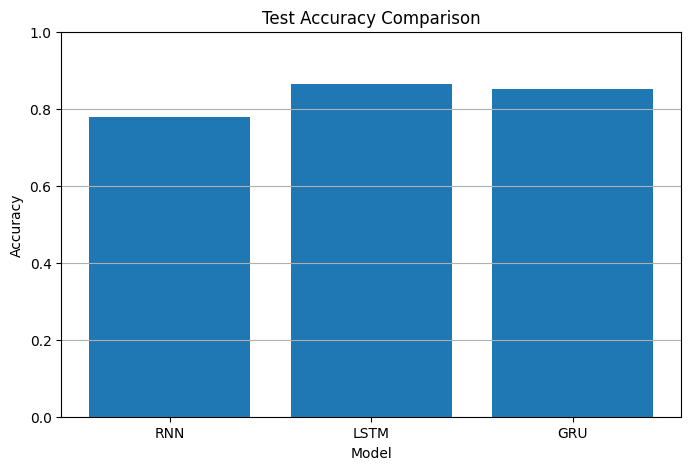

In [ ]:
# Accuracy Comparison Bar Chart

plt.figure(figsize=(8, 5))
plt.bar(result_df["Model"], result_df["Test Accuracy"])
plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

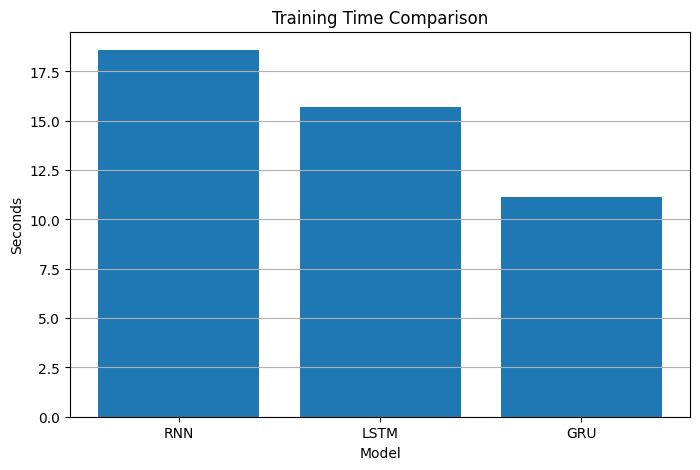

In [ ]:
# Training Time Comparison
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(result_df["Model"], result_df["Training Time Seconds"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.grid(axis="y")
plt.show()

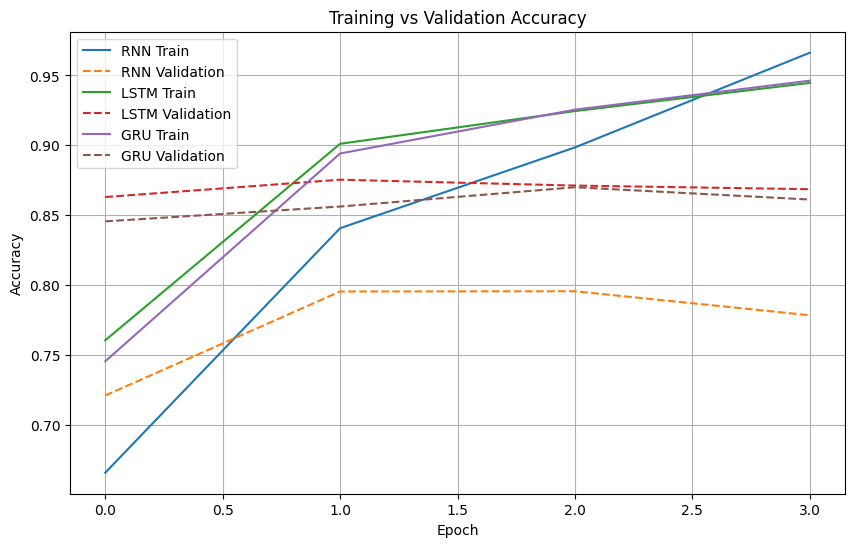

In [ ]:
# Accuracy Curves
# -----------------------------
plt.figure(figsize=(10, 6))

for name in model_names:
    plt.plot(histories[name].history["accuracy"], label=f"{name} Train")
    plt.plot(histories[name].history["val_accuracy"], linestyle="--", label=f"{name} Validation")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

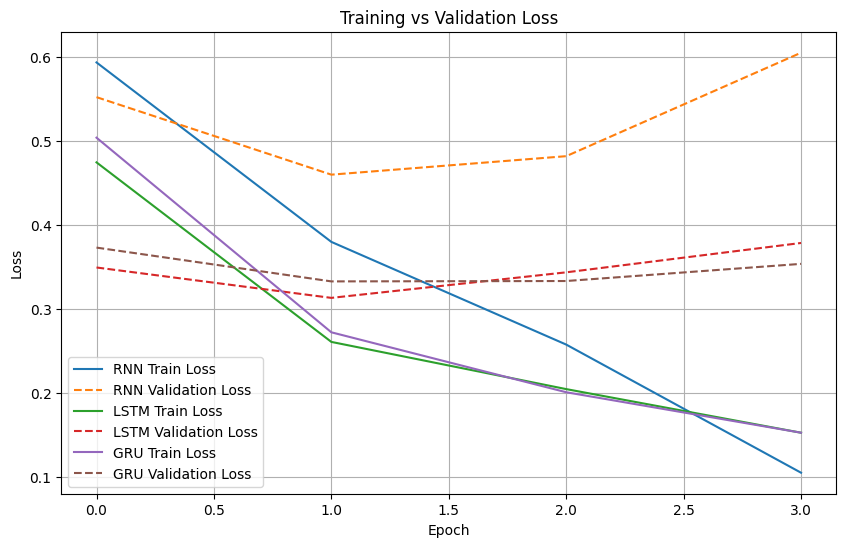

In [ ]:
# Loss Curves
# -----------------------------
plt.figure(figsize=(10, 6))

for name in model_names:
    plt.plot(histories[name].history["loss"], label=f"{name} Train Loss")
    plt.plot(histories[name].history["val_loss"], linestyle="--", label=f"{name} Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Best Model: LSTM
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step


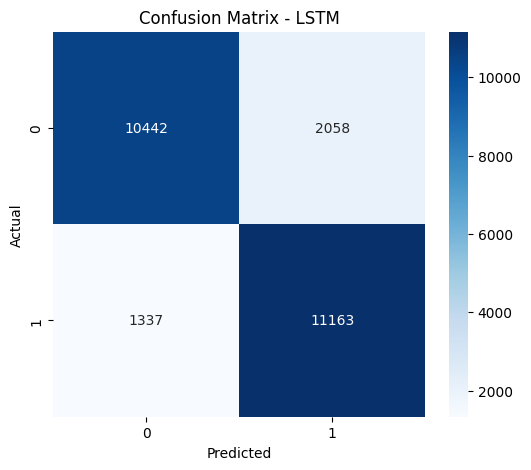

              precision    recall  f1-score   support

           0       0.89      0.84      0.86     12500
           1       0.84      0.89      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.87      0.86      0.86     25000
weighted avg       0.87      0.86      0.86     25000



In [ ]:
# Confusion Matrix for Best Model
# -----------------------------
best_model_name = result_df.sort_values("Test Accuracy", ascending=False).iloc[0]["Model"]
best_model = results[best_model_name]["model"]

print("Best Model:", best_model_name)

y_pred = best_model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred_classes))